# Day 10 — Message Passing / GNN Foundations

> 主线：**为什么 shallow embedding 不够 → 为什么图不能直接套普通 MLP → permutation invariance / equivariance → local neighborhood → AGGREGATE + UPDATE → k-hop → deep encoder**

今天不把 GCN 公式一次性学完。**Day 11 再正式进入 GCN / normalization / `GCNConv` / 手搓 `SimpleGCNConv`。**

## 今日验收
1. shallow embedding 为什么是 transductive？
2. 为什么图不能直接把 `A + X` flatten 后塞进普通 MLP？
3. permutation invariant 和 permutation equivariant 有什么区别？
4. 一层 message passing 到底对一个 node 做了什么？
5. 为什么 `sum / mean / max` 适合作为邻居聚合？
6. 为什么堆叠 $K$ 层后能获得 $K$-hop 信息？
7. GNN 为什么是 deep encoder，而 shallow embedding 只是 lookup？

## 0. Day 9 → Day 10：为什么要从 shallow encoder 走向 GNN？

Day 9 的 shallow encoder 本质是 embedding lookup：

$$
u \longrightarrow z_u
$$

它的问题是：参数量随节点数增长、不共享参数、天然 transductive，而且不能自然利用 node feature。

所以我们希望学习一个统一函数：

$$
z_v=f\big(x_v,\{x_u:u\in N(v)\}\big)
$$

也就是：**根据自己 + 邻居，现场算 representation。**

### 必须回答 0
为什么下面两件事本质不同？

```text
shallow embedding:
node id → lookup → z_v

GNN:
node feature + neighbor information → learned function → z_v
```

你的回答： Shallow embedding 是直接为每个已知节点学习并存储一个独立的 embedding，本质上更像“记住每个节点自己的表示”；而 GNN 学习的是一个共享的表示生成函数，通过节点自身 feature 和邻居信息来计算 embedding，因此能够把这种规则应用到不同节点，甚至新节点

## 1. 为什么 Graph 需要专门的 Neural Network？

图有几个特殊点：

- 图大小可以变化
- 拓扑结构不规则
- 没有天然固定的 node ordering
- 每个 node 的邻居数量不同
- node / edge 可能有自己的 feature

所以最朴素的：

```text
[A, X] → flatten → MLP
```

会有问题：只要重新编号 node，矩阵排列就变了，但图本身没有变。

In [2]:
import torch
import torch.nn as nn
import networkx as nx
import random
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)

print("torch:", torch.__version__)

torch: 2.14.0+cpu


## 2. Permutation Invariance vs. Equivariance

### Graph-level：Permutation Invariant

如果输入只是重新编号：

$$
(A,X)\rightarrow(PAP^T,PX)
$$

整张图的 representation 应该不变：

$$
f(A,X)=f(PAP^T,PX)
$$

### Node-level：Permutation Equivariant

如果输出是每个 node 一个 embedding，输入 node 顺序变了，输出也应该按同样方式重排：

$$
Pf(A,X)=f(PAP^T,PX)
$$

也就是：**输入怎么换顺序，node embeddings 就跟着同样换顺序。**

邻居集合：

```text
N(v) = {a, b, c}
```

和：

```text
N(v) = {c, a, b}
```

是同一批邻居。

所以聚合函数应该对顺序不敏感。`SUM / MEAN / MAX` 都满足这个直觉。

In [3]:
neighbors_1 = torch.tensor([
    [1.0, 0.0],
    [0.0, 2.0],
    [3.0, 1.0],
])

neighbors_2 = neighbors_1[[2, 0, 1]]

mean_1 = neighbors_1.mean(dim=0)
mean_2 = neighbors_2.mean(dim=0)

print("mean_1 =", mean_1)
print("mean_2 =", mean_2)
print("same?  =", torch.allclose(mean_1, mean_2))

mean_1 = tensor([1.3333, 1.0000])
mean_2 = tensor([1.3333, 1.0000])
same?  = True


### 必须回答 1
为什么 `mean()` 不在乎邻居顺序，而普通“把所有邻居按某个顺序 concatenate 后送进 MLP”会对顺序敏感？

你的回答：mean() 对邻居顺序不敏感，因为无论邻居怎么排列，求平均的结果都一样，因此适合作为 permutation-invariant aggregation；而 concatenate 会把邻居按照具体顺序拼接，顺序变化会导致输入向量变化，从而使后续 MLP 输出也变化，因此不适合作为无序邻居集合的直接聚合方式

## 3. Local Neighborhood 定义 Computation Graph

对目标节点 $v$：

- 1 层：吸收 1-hop neighbors
- 2 层：吸收 2-hop 信息
- $K$ 层：理论上可以获得 $K$-hop 范围的信息

Layer 0 是输入 node feature：

$$
h_v^{(0)}=x_v
$$

最终：

$$
z_v=h_v^{(K)}
$$

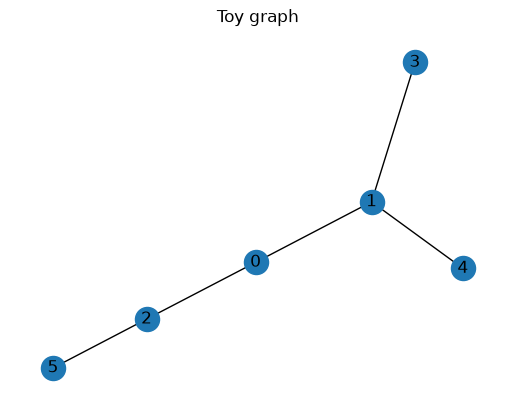

In [4]:
G = nx.Graph()
G.add_edges_from([
    (0, 1), (0, 2),
    (1, 3), (1, 4),
    (2, 5)
])

pos = nx.spring_layout(G, seed=SEED)
nx.draw_networkx(G, pos=pos)
plt.title("Toy graph")
plt.axis("off")
plt.show()

In [5]:
def k_hop_nodes(G, start, k):
    seen = {start}
    frontier = {start}

    for _ in range(k):
        next_frontier = set()
        for u in frontier:
            next_frontier.update(G.neighbors(u))
        next_frontier -= seen
        seen |= next_frontier
        frontier = next_frontier

    seen.remove(start)
    return seen

print("1-hop of node 0:", k_hop_nodes(G, 0, 1))
print("2-hop of node 0:", k_hop_nodes(G, 0, 2))

1-hop of node 0: {1, 2}
2-hop of node 0: {1, 2, 3, 4, 5}


### 必须回答 2
为什么堆两层 message passing 后，node 0 能拿到 node 3 / 4 / 5 的信息，即使它们不是 node 0 的直接邻居？

你的回答：第一层时，node 1 和 node 2 分别聚合自己的 1-hop 邻居，因此 h_1 已包含 node 3、4 的信息，h_2 已包含 node 5 的信息；第二层 node 0 再聚合 h_1 和 h_2 ，于是就间接获得了 3、4、5 的 2-hop 信息。

## 4. 一层 GNN = AGGREGATE + UPDATE

$$
m_v^{(k)}
=
\operatorname{AGGREGATE}^{(k)}
\left(
\{h_u^{(k)}:u\in N(v)\}
\right)
$$

$$
h_v^{(k+1)}
=
\operatorname{UPDATE}^{(k)}
\left(
h_v^{(k)},m_v^{(k)}
\right)
$$

通俗地说：

```text
邻居们当前的 h
      ↓
  AGGREGATE
      ↓
邻居总结 m_v
      ↓
和自己的 h_v 一起 UPDATE
      ↓
新的 h_v
```

## 5. 手搓最小版 Mean Message Passing

我们故意不用 PyG。

$$
h_v^{(k+1)}
=
\sigma\left(
W_{\text{nbr}}^{(k)}
\operatorname{mean}_{u\in N(v)}h_u^{(k)}
+
W_{\text{self}}^{(k)}h_v^{(k)}
\right)
$$

这只是最容易看懂的 message-passing prototype，不是要求背成“唯一 GNN 公式”。

In [6]:
X = torch.tensor([
    [1.0, 0.0, 0.5],
    [0.5, 1.0, 0.0],
    [0.0, 1.0, 1.0],
    [1.0, 1.0, 0.0],
    [0.0, 0.5, 1.0],
    [1.0, 0.0, 1.0],
])

print("X.shape =", X.shape)

X.shape = torch.Size([6, 3])


In [11]:
def mean_aggregate_one_node(G, H, v):
    nbrs = list(G.neighbors(v))

    if len(nbrs) == 0:
        return torch.zeros(H.shape[1], dtype=H.dtype)

    nbrs_embeddings = H[nbrs]
    return nbrs_embeddings.mean(dim=0)

for v in G.nodes():
    print(f"node {v}: neighbor mean =", mean_aggregate_one_node(G, X, v))

node 0: neighbor mean = tensor([0.2500, 1.0000, 0.5000])
node 1: neighbor mean = tensor([0.6667, 0.5000, 0.5000])
node 2: neighbor mean = tensor([1.0000, 0.0000, 0.7500])
node 3: neighbor mean = tensor([0.5000, 1.0000, 0.0000])
node 4: neighbor mean = tensor([0.5000, 1.0000, 0.0000])
node 5: neighbor mean = tensor([0., 1., 1.])


如果 `nbrs = [1, 2]`：

```text
H[nbrs]
→ 取 node 1 和 node 2 的两行
→ shape = [2, hidden_dim]
```

然后：

```python
.mean(dim=0)
```

沿邻居维求平均，得到：

```text
[hidden_dim]
```

In [12]:
class ToMeanMessagePassing(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W_nbrs = nn.Linear(in_dim, out_dim, bias=False)
        self.W_self = nn.Linear(in_dim, out_dim, bias=True)

    def forward(self, G, H):
        out = []

        for v in G.nodes():
            m_v = mean_aggeragate_one_node(G, H, v)
            h_new = self.W_nbrs(m_v) + self.W_self(H[v])
            h_new = torch.relu(h_new)
            out.append(h_new)

        return out

In [14]:
layer1 = ToyMeanMessagePassing(in_dim=3, out_dim=4)
H1 = layer1(G, X)

print("X shape :", X.shape)
print("H1 shape:", H1.shape)
print(H1)

X shape : torch.Size([6, 3])
H1 shape: torch.Size([6, 4])
tensor([[0.0000, 0.0000, 0.0000, 0.5180],
        [0.0000, 0.0000, 0.0000, 0.0784],
        [0.3983, 0.0000, 0.0000, 0.0762],
        [0.0000, 0.1856, 0.0000, 0.6259],
        [0.1302, 0.0000, 0.0000, 0.7684],
        [0.3186, 0.0000, 0.0000, 0.6169]], grad_fn=<StackBackward0>)


### 必须回答 3
假设 `hidden_dim = d`，`degree(v) = m`，下面 shape 分别是什么？

```text
H[v]
H[nbrs]
mean_aggregate_one_node(G, H, v)
```

你的回答：[d], [m, d], [d]

## 6. 两层 Message Passing：1-hop → 2-hop

$$
H^{(0)}=X
$$

$$
H^{(1)}=\text{MP}_1(G,H^{(0)})
$$

$$
H^{(2)}=\text{MP}_2(G,H^{(1)})
$$

第二层看到的邻居 $H^{(1)}$ 已经包含了邻居自己的 1-hop 信息，因此 $H_v^{(2)}$ 能间接包含 2-hop 信息。

In [15]:
layer2 = ToyMeanMessagePassing(in_dim=4, out_dim=2)
H2 = layer2(G, H1)

print("H0 / X:", X.shape)
print("H1    :", H1.shape)
print("H2    :", H2.shape)
print(H2)

H0 / X: torch.Size([6, 3])
H1    : torch.Size([6, 4])
H2    : torch.Size([6, 2])
tensor([[0.0000, 0.0000],
        [0.0000, 0.0042],
        [0.0000, 0.1579],
        [0.0000, 0.0000],
        [0.0000, 0.0000],
        [0.0000, 0.0000]], grad_fn=<StackBackward0>)


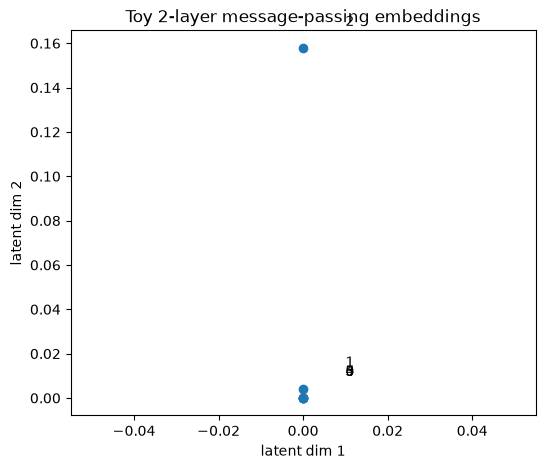

In [16]:
Z = H2.detach()

plt.figure(figsize=(6, 5))
plt.scatter(Z[:, 0], Z[:, 1])

for i in range(Z.shape[0]):
    plt.text(Z[i, 0].item() + 0.01,
             Z[i, 1].item() + 0.01,
             str(i))

plt.xlabel("latent dim 1")
plt.ylabel("latent dim 2")
plt.title("Toy 2-layer message-passing embeddings")
plt.show()

## 7. Shared Parameters：GNN 和 shallow embedding 的关键区别

所有 node 都共用：

```python
layer1.W_nbr
layer1.W_self
```

而不是每个 node 自己一套参数。

因此 GNN 学到的是：

> **如何聚合和变换 neighborhood information 的规则**

而不是：

> **每个 node 单独背一个 embedding。**

### 必须回答 4
如果 test time 新来 node 6，并且我们知道 `x_6` 和 `neighbors(6)`，为什么这个 GNN 有机会直接算 $h_6$，而 Day 9 的 `nn.Embedding(num_nodes, d)` 做不到？

你的回答：因为整张graph用的是一套完全形同的参数，新来的点只要在这套参数下训练就被表征

## 8. 课件里的基础 GNN Update

课件给出的基础形式可以理解为：

$$
h_v^{(k+1)}
=
\sigma\left(
W_k
\frac{1}{|N(v)|}
\sum_{u\in N(v)}
h_u^{(k)}
+
B_k h_v^{(k)}
\right)
$$

- $h_v^{(0)}=x_v$
- 邻居先 mean aggregate
- $W_k$：变换 neighbor message
- $B_k$：变换 self representation
- $\sigma$：非线性
- $h_v^{(K)}$：最终 node embedding

今天理解 **AGGREGATE + UPDATE 的结构** 即可。

## 9. Matrix View：今天只建立直觉

如果所有 node embedding 堆成：

$$
H^{(k)}\in\mathbb R^{|V|\times d}
$$

邻居求和可以通过：

$$
AH^{(k)}
$$

邻居 mean 可以直觉写成：

$$
D^{-1}AH^{(k)}
$$

实际 GNN 会用高效 sparse matrix / message-passing kernel 批量完成，而不会真的 Python `for node` 一个一个算。

**Day 11 再进入 GCN 的 symmetric normalization。**

In [19]:
A = torch.tensor(nx.to_numpy_array(G), dtype=torch.float32)
neighbor_sum_matrix = A @ X

for v in G.nodes():
    nbrs = list(G.neighbors(v))
    manual_sum = X[nbrs].sum(dim=0) if nbrs else torch.zeros(X.shape[1])

    print(f"node {v}:",
          torch.allclose(neighbor_sum_matrix[v], manual_sum))

node 0: True
node 1: True
node 2: True
node 3: True
node 4: True
node 5: True


In [20]:
degree = A.sum(dim=1, keepdim=True)
neighbor_mean_matrix = (A @ X) / degree.clamp(min=1)

manual_means = torch.stack([
    mean_aggregate_one_node(G, X, v)
    for v in G.nodes()
])

print("matrix mean == manual mean ?",
      torch.allclose(neighbor_mean_matrix, manual_means))

matrix mean == manual mean ? True


### 必须回答 5
为什么：

$$
AH
$$

能够得到“每个 node 的邻居 embedding 之和”？

提示：邻接矩阵第 $v$ 行的 $A_{vu}$ 只有在 $u\in N(v)$ 时才为 1。

你的回答：因为矩阵乘法中，AH 的第 v 行为 A_vu 和 h_u 相乘再求和。而邻接矩阵中，只有当 u 是 v 的邻居时， A_vu=1，其他位置为 0，因此非邻居的 embedding 会被乘成 0，只剩下所有邻居 embedding 的求和

## 10. Day 10 最终知识图

```text
Day 9 shallow embedding
        ↓
每个 node 单独 lookup
        ↓
transductive / 不共享参数 / 不自然利用 node feature
        ↓
希望学统一的 encoder
        ↓
Graph 没有固定 node ordering
        ↓
需要 permutation-aware architecture
        ↓
local neighborhood defines computation graph
        ↓
AGGREGATE neighbor representations
        ↓
UPDATE with self representation
        ↓
stack K layers
        ↓
K-hop information
        ↓
deep GNN encoder
```

### 今天不要求掌握
- $\tilde A=A+I$
- symmetric normalization
- $\tilde D^{-1/2}\tilde A\tilde D^{-1/2}$
- PyG `GCNConv` 内部细节

这些放到 **Day 11：GCN 从公式到手搓**。

# Day 10 最终自测

1. shallow encoder 为什么是 transductive？
2. GNN 为什么比 embedding lookup 更有 inductive potential？
3. 图为什么要求 permutation invariance / equivariance？
4. graph-level invariance 与 node-level equivariance 区别是什么？
5. `AGGREGATE` 在聚合什么？
6. `UPDATE` 又在更新什么？
7. 为什么 mean / sum 不依赖 neighbor ordering？
8. 为什么两层 message passing 能获得 2-hop 信息？
9. 为什么所有 node 共用同一组 $W$ 很重要？
10. $AH$ 为什么等于邻居 hidden states 的求和？

完成后进入 **Day 11：GCN**。